In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.colors import ListedColormap, BoundaryNorm
import csv
from concave_hull import concave_hull, concave_hull_indexes
from shapely.geometry import Polygon


In [2]:
# import the needed data for each framework

def import_all_simulation_data_for_tissue_size(framework_head, framework_location, optional_key=None):
    # framework = '1000_Data/' +  framework_head +'_MonolayerGrowth_1000_Data/'
    framework = framework_location
    num_files = len([f for f in os.listdir(framework) if os.path.isfile(os.path.join(framework, f))])

    # Aggregate data from all 100 simulations
    total_number_of_cells = []
    tissue_areas = []
    tissue_perimeters = []
    tissue_roughnesses = []


    if framework_head == 'TST' or framework_head == 'Artistoo' or framework_head == 'Morpheus':
        iter_vals = np.arange(0, 46*num_files, 46)
    elif framework_head == 'Chaste':
        iter_vals = range(0, num_files-2)
    else:
        iter_vals = range(0, num_files-1)


    for index in iter_vals:
        if framework_head == 'Artistoo':
            file_path = os.path.join(framework, f'cell_data_no_inhibition_{index:03d}.csv')
        elif framework_head == 'CC3D':
            file_path = os.path.join(framework, f'cell_data_no_inhibition_{index:03d}.csv')
        elif framework_head == 'PhysiCell' or framework_head == 'PolyHoop':
            file_path = os.path.join(framework, f'data{index:06d}.csv')
        else:
            file_path = os.path.join(framework, f'cell_data_no_inhibition_{index}.csv')

        if framework_head == 'Morpheus':
            data = np.loadtxt(file_path, delimiter='\t', skiprows=1)
        elif framework_head == 'CC3D':
            data = np.loadtxt(file_path, delimiter=',', skiprows=1)
        else:
            data = np.loadtxt(file_path, delimiter=',', skiprows=1)
        
        
        if data.ndim == 2:
            number_of_cells = data.shape[0]
        else:
            number_of_cells = 1
            

        if number_of_cells < 3:

            if number_of_cells == 1:
                hull_area = np.pi * data[2]**2
                # hull_perimeter = 2 * np.pi * data[2]

                hull_perimeter = 2 * np.pi * data[2]
                roughness = hull_perimeter / (2*np.pi * np.sqrt(hull_area/np.pi))

                hull_perimeter = np.sqrt(hull_area/np.pi)

            else:
                hull_area = 0
                hull_perimeter = 0
                roughness = 0
                for i in range(number_of_cells):
                    hull_area += np.pi * data[i,2]**2
                    hull_perimeter += 2 * np.pi * data[i,2]
                roughness += hull_perimeter / (2*np.pi * np.sqrt(hull_area/np.pi))
                hull_perimeter = np.sqrt(hull_area/np.pi)

        else:
            x_vals = data[:,0]
            y_vals = data[:,1]

            # create 2D numpy array of points
            points = np.column_stack((x_vals, y_vals))
            hull_indexes = concave_hull_indexes(points, concavity = 1.5, length_threshold = 0.0)
            hull_points = concave_hull(points[hull_indexes])

            # find the area of the concave hull
            hull_polygon = Polygon(hull_points)
            hull_area = hull_polygon.area
            # print(f"Concave hull area: {hull_area}")

            # calculate the length of the concave hull perimeter
            hull_perimeter = hull_polygon.length
            roughness = hull_perimeter / (2*np.pi * np.sqrt(hull_area/np.pi))

            centroid = points.mean(axis=0)

            p1 = hull_points[:-1]
            p2 = hull_points[1:]

            # Midpoint of each edge
            midpoints = 0.5 * (p1 + p2)

            # Length of each edge (the weight)
            edge_lengths = np.linalg.norm(p2 - p1, axis=1)

            # Distance from centroid to each edge midpoint
            mid_distances = np.linalg.norm(midpoints - centroid, axis=1)

            # Weighted average
            radius = np.sum(mid_distances * edge_lengths) / np.sum(edge_lengths)
            
            hull_perimeter = radius
            
            # print(f"Roughness: {roughness}")

        total_number_of_cells.append(number_of_cells)
        tissue_areas.append(hull_area)
        tissue_perimeters.append(hull_perimeter)
        tissue_roughnesses.append(roughness)
    return total_number_of_cells, tissue_areas, tissue_perimeters, tissue_roughnesses

In [3]:
def import_data_files_for_timeseries_plots(index, key, file_index):

    head = "/Users/dger0683/ChasteWorkspace/chaste_output/New/NoInhibition_strong_100/"

    # import the data file : results.viznodes. 
    # data_rad_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/cellareas.dat"
    data_rad_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_Radius.dat"
    if not os.path.isfile(data_rad_file):
        print(f"Data file {data_rad_file} not found.")
        sys.exit(1)

    data_surf_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_FreeSurfaceFraction.dat"
    if not os.path.isfile(data_surf_file):
        print(f"Data file {data_surf_file} not found.")
        sys.exit(1)

    data_area_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_FreeAreaFraction.dat"
    if not os.path.isfile(data_area_file):
        print(f"Data file {data_area_file} not found.")
        sys.exit(1)

    inhibited_growth_file = f"{head}/{key}/MonolayerGrowth_Beta_Index{index}/results_from_time_0/celldata_growth inhibited.dat"
    if not os.path.isfile(inhibited_growth_file):
        print(f"Data file {inhibited_growth_file} not found.")
        sys.exit(1)
    # extract the relavent data from the files
    # open the loggedcell.dat file, and go straight to the last row
    data_list = []
    with open(data_rad_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_list.append(row)

    final_row = data_list[file_index][1:]
    # print(f"Final row (excluding time): {final_row}")
    x_vals = final_row[2::5]
    y_vals = final_row[3::5]
    r_vals = final_row[4::5]
    # for i in range(len(r_vals)):
    #     r_vals[i] = np.sqrt(r_vals[i]/np.pi)

    data_surf = []
    with open(data_surf_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_surf.append(row)
    surface_fractions = data_surf[file_index][5::5]


    data_area = []
    with open(data_area_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_area.append(row)
    area_fractions = data_area[file_index][5::5]

    data_inhibited = []
    with open(inhibited_growth_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                row = list(map(float, line.split()))
                data_inhibited.append(row)
    inhibited_cells = data_inhibited[file_index][5::5]

    time_point = data_list[file_index][0]

    return x_vals, y_vals, r_vals, surface_fractions, area_fractions, inhibited_cells, time_point


In [4]:
def clean_time_series_data_and_calculate_mean(framework, directory):
    # 1) Load + store all simulation data (no plotting here)
    simulation_data = []

    if framework == 'Chaste':
        final_area = 2.0
        final_radius = np.sqrt(final_area/np.pi)
    else:
        final_area = 1
        final_radius = 1

    for sim_index in range(100):
        print(f"Processing simulation {sim_index} for framework {framework}...")
        if framework == 'Chaste':
            number_of_cells, tissue_areas, tissue_perimeters, tissue_roughnesses = import_all_simulation_data_for_tissue_size(
                framework,
                f'{directory}/Sim_{sim_index}/'
            )
            read_csv_file = f'{directory}/Sim_{sim_index}/timeline.txt'
        elif framework == 'TST':
            number_of_cells, tissue_areas, tissue_perimeters, tissue_roughnesses = import_all_simulation_data_for_tissue_size(
                framework,
                f'{directory}/run{sim_index+1}/'
            )
            # t = np.arange(0, len(number_of_cells), 46)
            # t = t / 183.0
        else:
            number_of_cells, tissue_areas, tissue_perimeters, tissue_roughnesses = import_all_simulation_data_for_tissue_size(
                framework,
                f'{directory}/run{sim_index+1}/'
            )
            read_csv_file = f'{directory}/run{sim_index+1}/timeline.txt'

        if framework != 'TST':
            t = []
            with open(read_csv_file, mode='r') as file:
                reader = csv.reader(file)
                next(reader)  # header
                for row in reader:
                    row_i = row[0].strip().split()
                    t.append(float(row_i[1]))

            t = np.array(t)
        elif framework == 'TST':
            t = np.arange(0, 46*len(number_of_cells), 46)
            t = t / (183.0 * 5.0)

        # "relative" versions (normalized by first value) for averaging shape across sims
        cells_rel = np.array(number_of_cells)
        # areas_rel = np.array(tissue_areas) / tissue_areas[0]
        # perims_rel = np.array(tissue_perimeters) / tissue_perimeters[0]
        # rough_rel = np.array(tissue_roughnesses) / tissue_roughnesses[0]
        areas_rel = np.array(tissue_areas)
        perims_rel = np.array(tissue_perimeters)
        rough_rel = np.array(tissue_roughnesses)
        # areas_rel = np.array(tissue_areas)/final_area
        # perims_rel = np.array(tissue_perimeters)/final_radius
        # rough_rel = np.array(tissue_roughnesses)

        # find the first time that number of cells is 2
        first_time_2_cells = None
        time_to_4_cells = None
        for i, num_cells in enumerate(cells_rel):
            if num_cells > 1 and first_time_2_cells is None:
                first_time_2_cells = i - 1
            elif num_cells > 3 and time_to_4_cells is None:
                time_to_4_cells = i
                break
        prefered_area = tissue_areas[first_time_2_cells]

        # now set everything before time_to_4_cells to nan
        for i in range(time_to_4_cells):
            tissue_areas[i] = np.nan
            tissue_perimeters[i] = np.nan
            tissue_roughnesses[i] = np.nan

            areas_rel[i] = np.nan
            perims_rel[i] = np.nan
            rough_rel[i] = np.nan

        simulation_data.append({
            "time": t,
            "cells": np.array(number_of_cells),
            "areas": np.array(tissue_areas),
            "perims": np.array(tissue_perimeters),
            "rough": np.array(tissue_roughnesses),
            "cells_rel": cells_rel,
            "areas_rel": areas_rel,
            "perims_rel": perims_rel,
            "rough_rel": rough_rel,
            "prefered_area": prefered_area
        })

    
    # Optional: save for reuse (skip recomputation next time)
    # np.savez("chaste_timeseries_cache.npz", simulation_data=np.array(simulation_data, dtype=object))

    # scale the raw data by the prefered area for each simulation
    mean_prefered_area = np.mean([d["prefered_area"] for d in simulation_data])
    for d in simulation_data:
        d["areas_rel"] = d["areas_rel"] / mean_prefered_area
        d["perims_rel"] = d["perims_rel"] / np.sqrt(mean_prefered_area/np.pi)

    # 2) Align to a common relative-time grid so averages are valid
    t_min = max(d["time"].min() for d in simulation_data)
    t_max = min(d["time"].max() for d in simulation_data)
    print(f"Common time range across simulations: {t_min} to {t_max}")
    common_t = np.linspace(t_min, t_max, 300)

    cells_rel_mat = np.vstack([np.interp(common_t, d["time"], d["cells_rel"]) for d in simulation_data])
    areas_rel_mat = np.vstack([np.interp(common_t, d["time"], d["areas_rel"]) for d in simulation_data])
    perims_rel_mat = np.vstack([np.interp(common_t, d["time"], d["perims_rel"]) for d in simulation_data])
    rough_rel_mat = np.vstack([np.interp(common_t, d["time"], d["rough_rel"]) for d in simulation_data])


    cells_rel_mean = cells_rel_mat.mean(axis=0)
    areas_rel_mean = areas_rel_mat.mean(axis=0) #/mean_prefered_area
    perims_rel_mean = perims_rel_mat.mean(axis=0) #/ np.sqrt(mean_prefered_area/np.pi)
    rough_rel_mean = rough_rel_mat.mean(axis=0)

    return common_t, cells_rel_mean, areas_rel_mean, perims_rel_mean, rough_rel_mean, simulation_data


In [5]:
from scipy.stats import wasserstein_distance

def wasserstein_from_timeseries(t1, y1, t2, y2):
    """
    Wasserstein-1 distance between two monotonic time series on different grids.

    Each series is treated as a 1D distribution over y-values, where the
    normalised time steps act as the probability weights.

    Args:
        t1, y1: time and values for series 1 (each length N, monotonic)
        t2, y2: time and values for series 2 (each length M, monotonic)

    Returns:
        Scalar Wasserstein-1 distance.
    """
    t1, y1 = np.asarray(t1, dtype=float), np.asarray(y1, dtype=float)
    t2, y2 = np.asarray(t2, dtype=float), np.asarray(y2, dtype=float)

    # Normalise each time grid independently to [0, 1]
    def time_weights(t):
        t_norm = (t - t[0]) / (t[-1] - t[0])
        return np.diff(t_norm, prepend=t_norm[0])

    return wasserstein_distance(y1, y2, u_weights=time_weights(t1),
                                        v_weights=time_weights(t2))

Processing simulation 0 for framework Chaste...
Processing simulation 1 for framework Chaste...
Processing simulation 2 for framework Chaste...
Processing simulation 3 for framework Chaste...
Processing simulation 4 for framework Chaste...
Processing simulation 5 for framework Chaste...
Processing simulation 6 for framework Chaste...
Processing simulation 7 for framework Chaste...
Processing simulation 8 for framework Chaste...
Processing simulation 9 for framework Chaste...
Processing simulation 10 for framework Chaste...
Processing simulation 11 for framework Chaste...
Processing simulation 12 for framework Chaste...
Processing simulation 13 for framework Chaste...
Processing simulation 14 for framework Chaste...
Processing simulation 15 for framework Chaste...
Processing simulation 16 for framework Chaste...
Processing simulation 17 for framework Chaste...
Processing simulation 18 for framework Chaste...
Processing simulation 19 for framework Chaste...
Processing simulation 20 for f

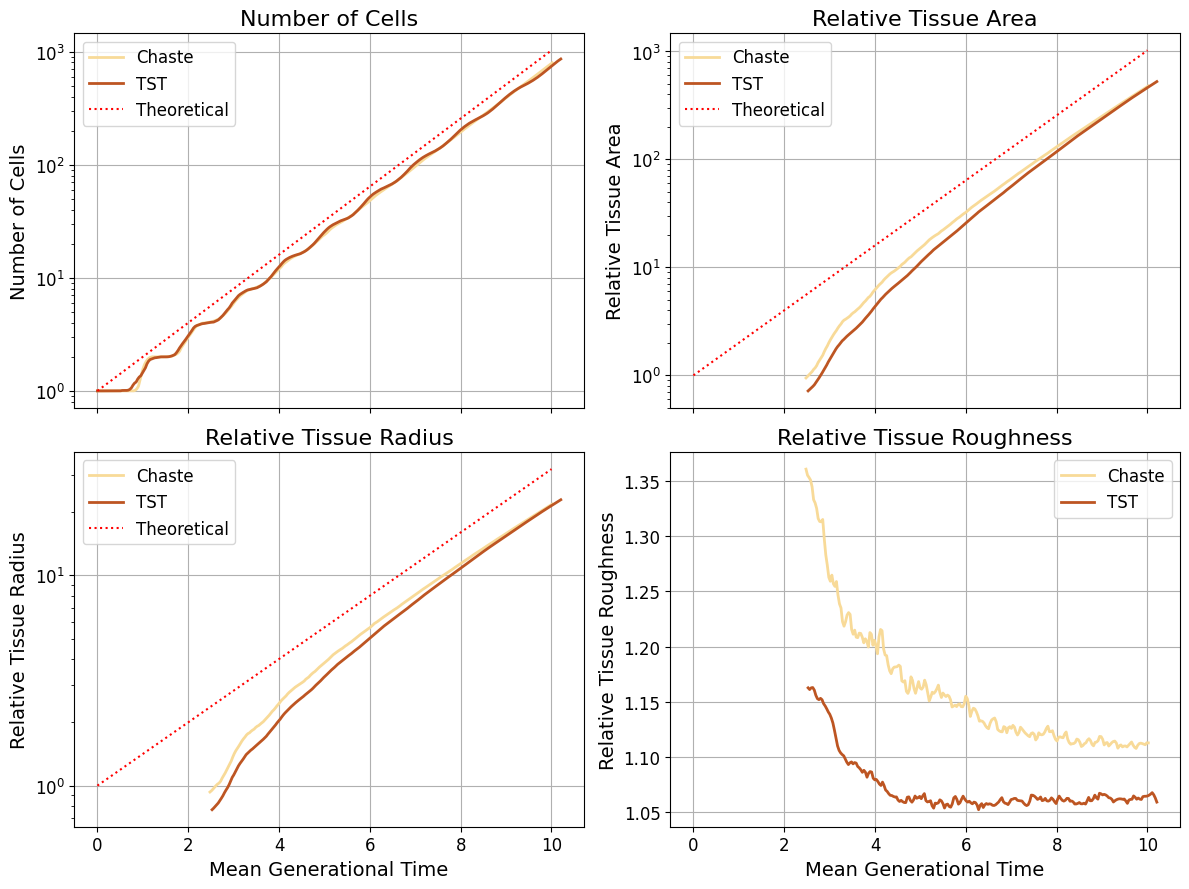

In [6]:
from matplotlib.colors import to_rgb


# 3) Plot all stored curves + average curve
fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
(ax_cells, ax_areas), (ax_perimeters, ax_roughness) = axs

ax_cells.set_title("Number of Cells", fontsize=16)
ax_areas.set_title("Relative Tissue Area", fontsize=16)
ax_perimeters.set_title("Relative Tissue Radius", fontsize=16)
ax_roughness.set_title("Relative Tissue Roughness", fontsize=16)


ax_cells.set_ylabel("Number of Cells", fontsize=14)
ax_areas.set_ylabel("Relative Tissue Area", fontsize=14)
ax_perimeters.set_ylabel("Relative Tissue Radius", fontsize=14)
ax_roughness.set_ylabel("Relative Tissue Roughness", fontsize=14)

ax_perimeters.set_xlabel("Mean Generational Time", fontsize=14)
ax_roughness.set_xlabel("Mean Generational Time", fontsize=14)

colors =[ (248/255, 218/255, 152/255),
          (189/255, 85/255, 34/255),
          (0/255, 0/255, 0/255),
          (100/255, 180/255, 194/255)]
# framework_labels = ['Chaste', 'PhysiCell', 'PolyHoop', 'TST']
# framework_labels = ['TST']
framework_labels = ['Chaste', 'TST']


iteration = 0
for framework in framework_labels:
    common_t, cells_rel_mean, areas_rel_mean, perims_rel_mean, rough_rel_mean, _ = clean_time_series_data_and_calculate_mean(framework, f'data/timeSeries/{framework}_MonolayerGrowth_1000_Data/')

    # mean curves
    ax_cells.plot(common_t, cells_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    ax_areas.plot(common_t, areas_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    ax_perimeters.plot(common_t, perims_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    ax_roughness.plot(common_t, rough_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    iteration += 1

# theoretical relative doubling curve (starts at 1)
theoretical_time_points = np.linspace(0, 10, 200)
theoretical_cell_counts = np.exp(theoretical_time_points * np.log(2))
theoretical_area = 2**(theoretical_time_points)  # area grows with the square of the radius, which grows with the number of cells
theoretical_perimeter =  2**(theoretical_time_points/2)  # perimeter grows linearly with the radius, which grows with the number of cells

ax_cells.plot(theoretical_time_points, theoretical_cell_counts, color='red', linestyle=':', label='Theoretical')
ax_areas.plot(theoretical_time_points, theoretical_area, color='red', linestyle=':', label='Theoretical')
ax_perimeters.plot(theoretical_time_points, theoretical_perimeter, color='red', linestyle=':', label='Theoretical')

for ax in [ax_cells, ax_areas, ax_perimeters, ax_roughness]:
    ax.grid(True)
    ax.legend()
    # font size of legend
    ax.legend(fontsize=12)

ax_cells.set_yscale('log')
ax_areas.set_yscale('log')
ax_perimeters.set_yscale('log')

# make all axis ticks font size 16
for ax in [ax_cells, ax_areas, ax_perimeters, ax_roughness]:
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

Processing simulation 0 for framework Chaste...
Processing simulation 1 for framework Chaste...
Processing simulation 2 for framework Chaste...
Processing simulation 3 for framework Chaste...
Processing simulation 4 for framework Chaste...
Processing simulation 5 for framework Chaste...
Processing simulation 6 for framework Chaste...
Processing simulation 7 for framework Chaste...
Processing simulation 8 for framework Chaste...
Processing simulation 9 for framework Chaste...
Common time range across simulations: 0.0 to 10.2864
Processing simulation 0 for framework PhysiCell...
Processing simulation 1 for framework PhysiCell...
Processing simulation 2 for framework PhysiCell...
Processing simulation 3 for framework PhysiCell...
Processing simulation 4 for framework PhysiCell...
Processing simulation 5 for framework PhysiCell...
Processing simulation 6 for framework PhysiCell...
Processing simulation 7 for framework PhysiCell...
Processing simulation 8 for framework PhysiCell...
Processi

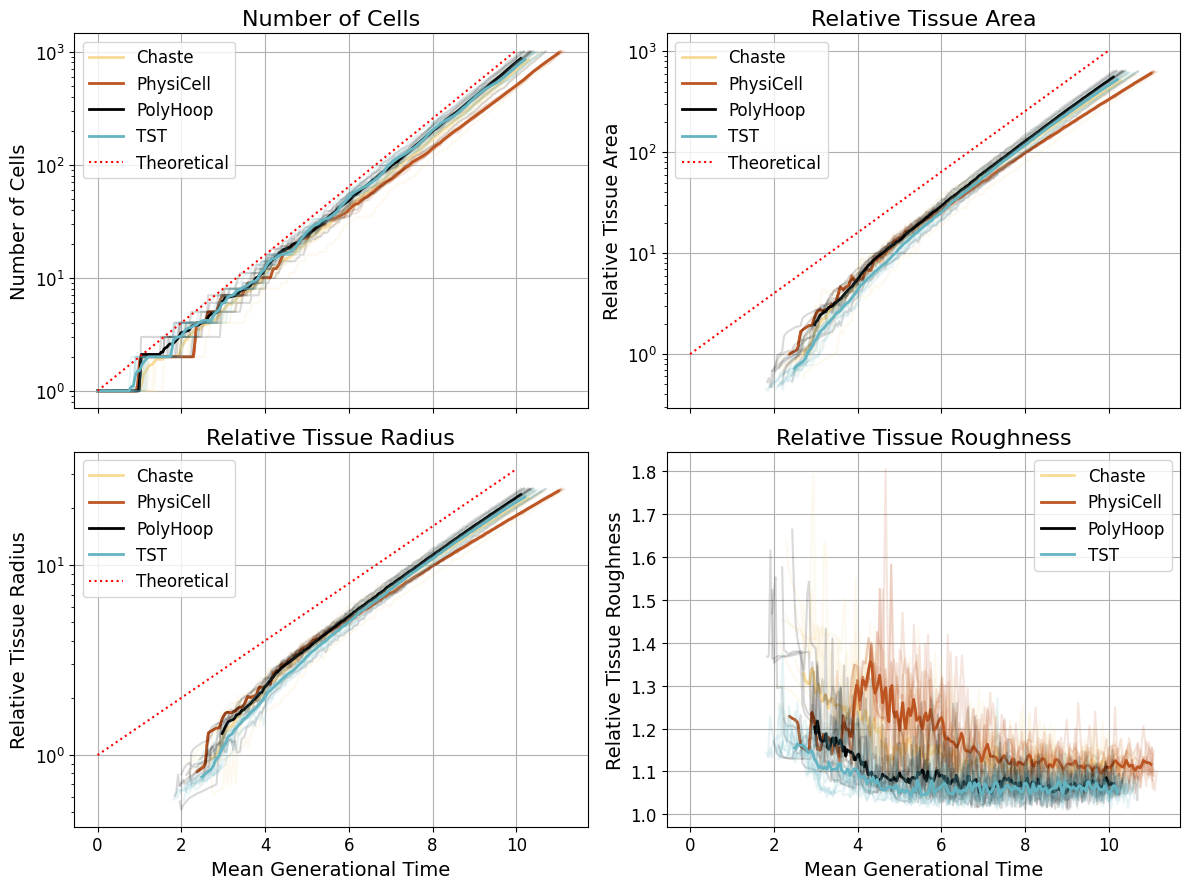

In [8]:
from matplotlib.colors import to_rgb


# 3) Plot all stored curves + average curve
fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
(ax_cells, ax_areas), (ax_perimeters, ax_roughness) = axs

ax_cells.set_title("Number of Cells", fontsize=16)
ax_areas.set_title("Relative Tissue Area", fontsize=16)
ax_perimeters.set_title("Relative Tissue Radius", fontsize=16)
ax_roughness.set_title("Relative Tissue Roughness", fontsize=16)


ax_cells.set_ylabel("Number of Cells", fontsize=14)
ax_areas.set_ylabel("Relative Tissue Area", fontsize=14)
ax_perimeters.set_ylabel("Relative Tissue Radius", fontsize=14)
ax_roughness.set_ylabel("Relative Tissue Roughness", fontsize=14)

ax_perimeters.set_xlabel("Mean Generational Time", fontsize=14)
ax_roughness.set_xlabel("Mean Generational Time", fontsize=14)

colors =[ (248/255, 218/255, 152/255),
          (189/255, 85/255, 34/255),
          (0/255, 0/255, 0/255),
          (100/255, 180/255, 194/255)]
framework_labels = ['Chaste', 'PhysiCell', 'PolyHoop', 'TST']

iteration = 0
for framework in framework_labels:
    common_t, cells_rel_mean, areas_rel_mean, perims_rel_mean, rough_rel_mean, simulation_data = clean_time_series_data_and_calculate_mean(framework, f'data/timeSeries/{framework}_MonolayerGrowth_1000_Data/')

    for sim_index, sim_data in enumerate(simulation_data):
        # plot the raw curves for this simulation with low alpha
        ax_cells.plot(sim_data["time"], sim_data["cells_rel"], color=colors[iteration], alpha=0.15)
        ax_areas.plot(sim_data["time"], sim_data["areas_rel"], color=colors[iteration], alpha=0.15)
        ax_perimeters.plot(sim_data["time"], sim_data["perims_rel"], color=colors[iteration], alpha=0.15)
        ax_roughness.plot(sim_data["time"], sim_data["rough_rel"], color=colors[iteration], alpha=0.15)
    
    # mean curves
    ax_cells.plot(common_t, cells_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    ax_areas.plot(common_t, areas_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    ax_perimeters.plot(common_t, perims_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    ax_roughness.plot(common_t, rough_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    iteration += 1

# theoretical relative doubling curve (starts at 1)
theoretical_time_points = np.linspace(0, 10, 200)
theoretical_cell_counts = np.exp(theoretical_time_points * np.log(2))
theoretical_area = 2**(theoretical_time_points)  # area grows with the square of the radius, which grows with the number of cells
theoretical_perimeter =  2**(theoretical_time_points/2)  # perimeter grows linearly with the radius, which grows with the number of cells

ax_cells.plot(theoretical_time_points, theoretical_cell_counts, color='red', linestyle=':', label='Theoretical')
ax_areas.plot(theoretical_time_points, theoretical_area, color='red', linestyle=':', label='Theoretical')
ax_perimeters.plot(theoretical_time_points, theoretical_perimeter, color='red', linestyle=':', label='Theoretical')

for ax in [ax_cells, ax_areas, ax_perimeters, ax_roughness]:
    ax.grid(True)
    ax.legend()
    # font size of legend
    ax.legend(fontsize=12)

ax_cells.set_yscale('log')
ax_areas.set_yscale('log')
ax_perimeters.set_yscale('log')

# make all axis ticks font size 16
for ax in [ax_cells, ax_areas, ax_perimeters, ax_roughness]:
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

Processing simulation 0 for framework Chaste...
Processing simulation 1 for framework Chaste...
Processing simulation 2 for framework Chaste...
Processing simulation 3 for framework Chaste...
Processing simulation 4 for framework Chaste...
Processing simulation 5 for framework Chaste...
Processing simulation 6 for framework Chaste...
Processing simulation 7 for framework Chaste...
Processing simulation 8 for framework Chaste...
Processing simulation 9 for framework Chaste...
Processing simulation 10 for framework Chaste...
Processing simulation 11 for framework Chaste...
Processing simulation 12 for framework Chaste...
Processing simulation 13 for framework Chaste...
Processing simulation 14 for framework Chaste...
Processing simulation 15 for framework Chaste...
Processing simulation 16 for framework Chaste...
Processing simulation 17 for framework Chaste...
Processing simulation 18 for framework Chaste...
Processing simulation 19 for framework Chaste...
Processing simulation 20 for f

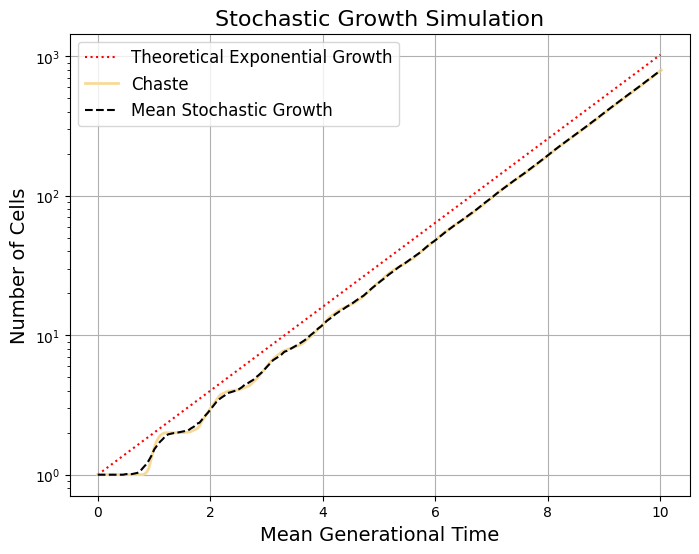

In [18]:
# simulate a theoretical stochastic growth curve using a simple birth process with a given growth rate
def simulate_stochastic_growth(mean_growth_time, total_time):
    number_of_cells = [1]
    noise_var = 0.4**2
    growth_time = [np.random.normal(mean_growth_time, noise_var,1)[0]]
    time_points = [0]
    t = 0
    while t < total_time:
        current_cells = number_of_cells[-1]
        
        growth_time_arr = np.asarray(growth_time, dtype=float).ravel()
        min_time_index = int(np.argmin(growth_time_arr))
        min_time = growth_time_arr[min_time_index]

        new_time = 0
        while new_time <= 0.0:
            new_time = np.random.normal(mean_growth_time, noise_var,1)[0]
        growth_time[min_time_index] = new_time + min_time
        new_time = 0
        while new_time <= 0.0:
            new_time = np.random.normal(mean_growth_time, noise_var,1)[0]
        growth_time.append(new_time + min_time)
        
        
        time_points.append(min_time)
        number_of_cells.append(current_cells)

        number_of_cells.append(current_cells + 1)
        t = min_time
        time_points.append(t)
    return time_points, number_of_cells

# perform the simulation 100 times and plot the results
simulation_data = []
for i in range(100):
    time_points, number_of_cells = simulate_stochastic_growth(mean_growth_time=1.0, total_time=10.0)
    # consolodate the data to the compute the mean curves later
    simulation_data.append({
        "time": time_points,
        "cells": number_of_cells
    })
    # plt.plot(time_points, number_of_cells, color='purple', alpha=0.1)

# find the max time that is common across all simulations (since they will have different time points due to the stochasticity)
t_min = max(d["time"][0] for d in simulation_data)
t_max = min(d["time"][-1] for d in simulation_data)
# interpolate the curves to a common time grid and compute the mean curve
common_time = np.linspace(t_min, t_max, 200)
cells_mat = np.vstack([np.interp(common_time, d["time"], d["cells"]) for d in simulation_data])
mean_cells = np.mean(cells_mat, axis=0)

theoretical_time_points = np.linspace(0, 10, 200)
theoretical_cell_counts = np.exp(theoretical_time_points * np.log(2))
plt.figure(figsize=(8,6))
plt.plot(theoretical_time_points, theoretical_cell_counts, color='red', linestyle=':', label='Theoretical Exponential Growth')

colors =[ (248/255, 218/255, 152/255),
          (189/255, 85/255, 34/255),
          (0/255, 0/255, 0/255),
          (100/255, 180/255, 194/255)]
# framework_labels = ['Chaste', 'PhysiCell', 'PolyHoop', 'TST']
framework_labels = ['Chaste']
iteration = 0
for framework in framework_labels:
    common_t, cells_rel_mean, _, _, _, simulation_data = clean_time_series_data_and_calculate_mean(framework, f'data/timeSeries/{framework}_MonolayerGrowth_1000_Data/')

    # for sim_index, sim_data in enumerate(simulation_data):
    #     # plot the raw curves for this simulation with low alpha
    #     plt.plot(sim_data["time"], sim_data["cells_rel"], color='black', alpha=0.15)
        
    # mean curves
    plt.plot(common_t, cells_rel_mean, color=colors[iteration], linewidth=2, label=framework_labels[iteration])
    iteration += 1

plt.plot(common_time, mean_cells, color='black', linestyle='--', label='Mean Stochastic Growth')

plt.xlabel('Mean Generational Time', fontsize=14)
plt.ylabel('Number of Cells', fontsize=14)
plt.title('Stochastic Growth Simulation', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.yscale('log')
plt.show()